In [16]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions

In [17]:
# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

In [18]:
# Load pretrained MobileNetV2
model = MobileNetV2(weights='imagenet')

import cv2
import numpy as np

def extract_frames(video_path, max_frames=20):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Cannot open video")
        return np.array([])

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Handle videos where frame count is 0
    if total_frames > 0:
        step = max(1, total_frames // max_frames)
    else:
        step = 1

    count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if count % step == 0:
            frame = cv2.resize(frame, (224, 224))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

        count += 1

        if len(frames) >= max_frames:
            break

    cap.release()
    print("Extracted frames:", len(frames))
    return np.array(frames)



def classify_video(video_path):
    frames = extract_frames(video_path)

    if len(frames) == 0:
        print("No frames extracted!")
        return

    frames = preprocess_input(frames)
    predictions = model.predict(frames)

    # Average predictions across frames
    avg_pred = np.mean(predictions, axis=0)
    #top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=1)

    top_pred = decode_predictions(np.expand_dims(avg_pred, axis=0), top=5)

    for pred in top_pred[0]:
      print(pred[1], ":", round(pred[2]*100, 2), "%")


    print("Final Prediction:", top_pred[0][0][1])

# Replace with your video path
video_path = "real_world_demo_video.mp4"
classify_video(video_path)

Extracted frames: 20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
digital_clock : 63.84 %
traffic_light : 9.13 %
switch : 1.43 %
computer_keyboard : 1.32 %
matchstick : 0.85 %
Final Prediction: digital_clock


Extracted frames: 20
Shape of frames: (20, 224, 224, 3)
First element (frame) of frames:


array([[[233, 206, 133],
        [233, 206, 133],
        [233, 206, 133],
        ...,
        [233, 206, 133],
        [233, 206, 133],
        [233, 206, 133]],

       [[233, 206, 133],
        [233, 206, 133],
        [233, 206, 133],
        ...,
        [233, 206, 133],
        [233, 206, 133],
        [233, 206, 133]],

       [[233, 206, 133],
        [233, 206, 133],
        [233, 206, 133],
        ...,
        [233, 206, 133],
        [233, 206, 133],
        [233, 206, 133]],

       ...,

       [[ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45],
        ...,
        [ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45]],

       [[ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45],
        ...,
        [ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45]],

       [[ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45],
        ...,
        [ 46,  48,  45],
        [ 46,  48,  45],
        [ 46,  48,  45]]], dtype=uint8)
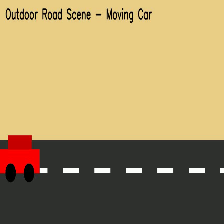

In [21]:
frames = extract_frames(video_path)

print("Shape of frames:", frames.shape)

if len(frames) > 0:
    print("First element (frame) of frames:")
    from IPython.display import display
    display(frames[0])
else:
    print("No frames were extracted.")


In [22]:
print(frames[0])

[[[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 [[233 206 133]
  [233 206 133]
  [233 206 133]
  ...
  [233 206 133]
  [233 206 133]
  [233 206 133]]

 ...

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]

 [[ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]
  ...
  [ 46  48  45]
  [ 46  48  45]
  [ 46  48  45]]]


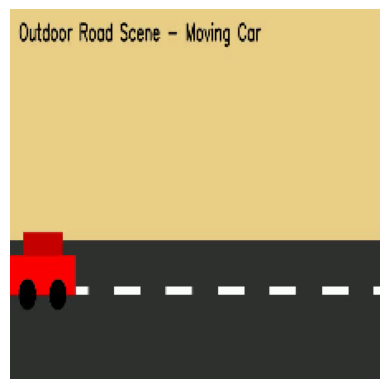

In [23]:
import matplotlib.pyplot as plt

plt.imshow(frames[0])
plt.axis('off') # Hide axes for a cleaner image display
plt.show()


Displaying the first 20 extracted frames and their pixel value summaries:

Frame 1 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.67
Frame 2 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.65
Frame 3 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.64
Frame 4 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.77
Frame 5 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.76
Frame 6 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.60
Frame 7 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.70
Frame 8 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.62
Frame 9 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.68
Frame 10 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.59
Frame 11 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.51
Frame 12 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.67
Frame 13 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.73
Frame 14 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.59
Frame 15 - Min Pixel: 0, Max Pixel: 255, Mean Pixel: 136.78
Frame 16 - Min Pixel: 0, Max Pixel

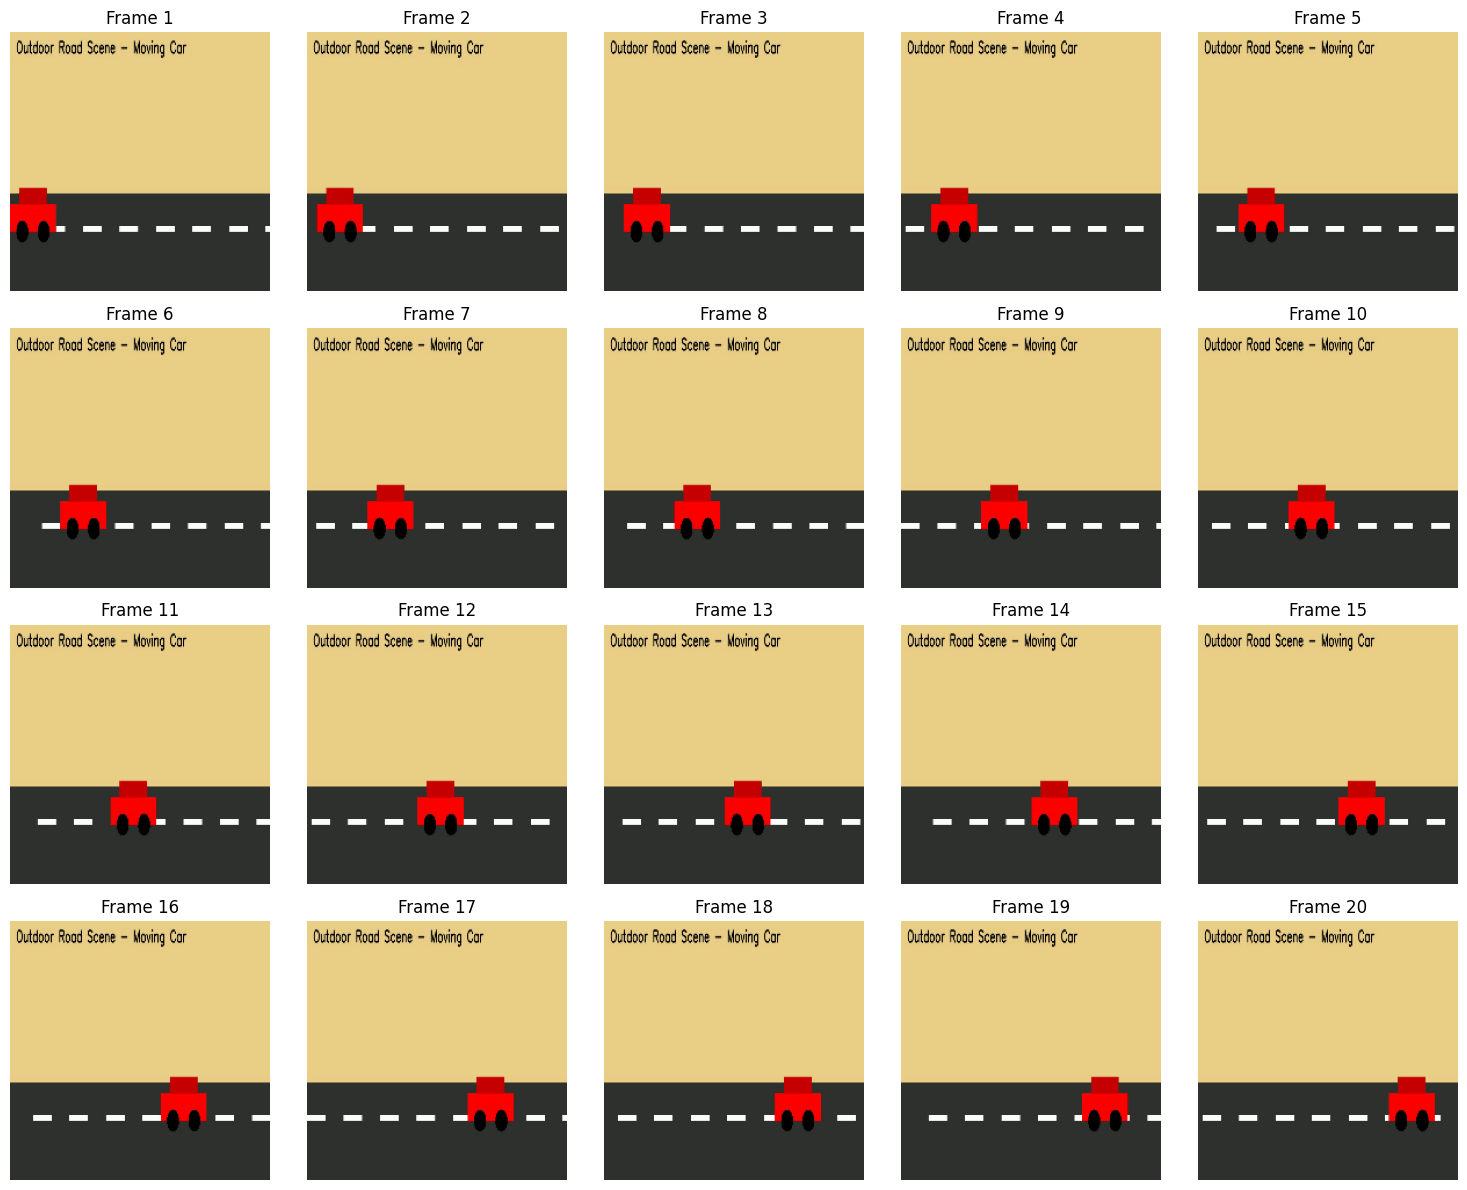

In [25]:
import matplotlib.pyplot as plt
import numpy as np

if len(frames) > 0:
    num_frames_to_display = min(20, len(frames))
    print(f"Displaying the first {num_frames_to_display} extracted frames and their pixel value summaries:\n")

    # Calculate grid dimensions (e.g., 4 rows, 5 columns for 20 images)
    rows = (num_frames_to_display + 4) // 5  # Ceiling division
    cols = 5

    plt.figure(figsize=(cols * 3, rows * 3))
    for i in range(num_frames_to_display):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(frames[i])
        plt.title(f"Frame {i+1}")
        plt.axis('off')

        # Print pixel value summary for the current frame below the plot
        min_val = np.min(frames[i])
        max_val = np.max(frames[i])
        mean_val = np.mean(frames[i])
        print(f"Frame {i+1} - Min Pixel: {min_val}, Max Pixel: {max_val}, Mean Pixel: {mean_val:.2f}")

    plt.tight_layout()
    plt.show()

else:
    print("No frames available to display images or pixel values.")
